# Homework Regression by Rizky Febri Ibra Habibie

| Column    | Description                                                                 |
| --------- | --------------------------------------------------------------------------- |
| `crim`    | Per capita crime rate by town                                               |
| `zn`      | Proportion of residential land zoned for lots over 25,000 sq.ft.            |
| `indus`   | Proportion of non-retail business acres per town                            |
| `chas`    | Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)       |
| `nox`     | Nitric oxides concentration (parts per 10 million)                          |
| `rm`      | Average number of rooms per dwelling                                        |
| `age`     | Proportion of owner-occupied units built prior to 1940                      |
| `dis`     | Weighted distances to five Boston employment centers                        |
| `rad`     | Index of accessibility to radial highways                                   |
| `tax`     | Full-value property tax rate per \$10,000                                   |
| `ptratio` | Pupil-teacher ratio by town                                                 |
| `black`   | $1000(Bk - 0.63)^2$ where $Bk$ is the proportion of Black residents by town |
| `lstat`   | % lower status of the population                                            |
| `medv`    | **Median value of owner-occupied homes in \$1000s** → 🎯 **target**         |


In [29]:
# STEP 0: Load Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [30]:
# STEP 1: Load Dataset
df = pd.read_csv('boston.csv')  # adjust path if necessary
X = df.drop(columns='medv')
y = df['medv']

In [31]:
X

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48


In [32]:
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: medv, Length: 506, dtype: float64

In [33]:
# STEP 2: Train-Validation-Test Split
X_pretrain, X_test, y_pretrain, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_pretrain, y_pretrain, test_size=0.2, random_state=42)

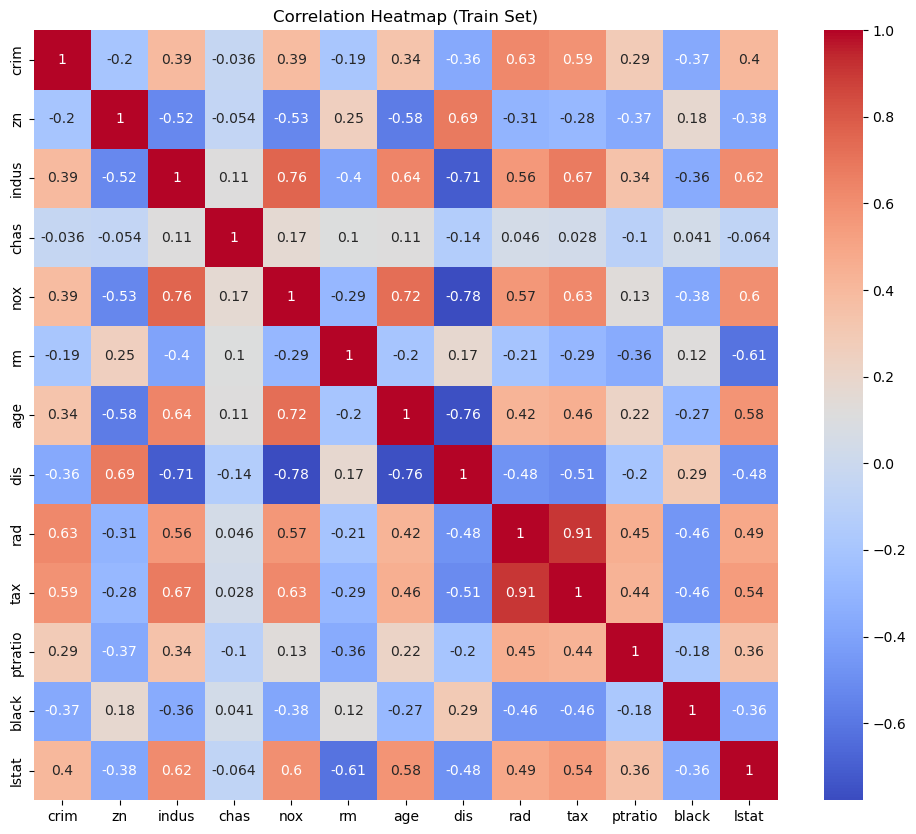

In [34]:
# STEP 3: Correlation Plot and Feature Selection
plt.figure(figsize=(12,10))
sns.heatmap(X_train.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Train Set)")
plt.show()

In [35]:
# Drop highly correlated features: 'rad' and 'tax' are highly correlated
X_train_sel = X_train.drop(columns='rad')
X_val_sel = X_val.drop(columns='rad')
X_test_sel = X_test.drop(columns='rad')

## Model Training

### Training Ridge model

In [36]:
# STEP 4: Train Ridge Models
lambdas = [0.01, 0.1, 1, 10]
ridge_rmse_results = []

for alpha in lambdas:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train_sel, y_train)
    y_val_pred = ridge_model.predict(X_val_sel)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    ridge_rmse_results.append((alpha, rmse))

ridge_rmse_results.sort(key=lambda x: x[1])
print("Ridge RMSE (sorted):", ridge_rmse_results)

Ridge RMSE (sorted): [(10, 4.871717983886228), (1, 4.912351371579993), (0.1, 4.949412535122792), (0.01, 4.9606769329578455)]


### Training Lasso Model

In [37]:
# STEP 5: Train Lasso Models
lasso_rmse_results = []

for alpha in lambdas:
    lasso_model = Lasso(alpha=alpha, max_iter=10000)
    lasso_model.fit(X_train_sel, y_train)
    y_val_pred = lasso_model.predict(X_val_sel)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    lasso_rmse_results.append((alpha, rmse))

lasso_rmse_results.sort(key=lambda x: x[1])
print("Lasso RMSE (sorted):", lasso_rmse_results)

Lasso RMSE (sorted): [(1, 4.8458559106363985), (0.1, 4.907145314259478), (0.01, 4.934105658639752), (10, 5.426622694252769)]


In [41]:
# STEP 6: Refit Best Models
best_ridge = Ridge(alpha=10)
best_ridge.fit(X_train_sel, y_train)

best_lasso = Lasso(alpha=1, max_iter=10000)
best_lasso.fit(X_train_sel, y_train)

Lasso(alpha=1, max_iter=10000)

## Model Interpretation

In [46]:
ridge = Ridge(alpha=10, random_state=42)
lasso = Lasso(alpha=1, max_iter=10000, random_state=42)

ridge.fit(X_train_sel, y_train)
lasso.fit(X_train_sel, y_train)

# Step: Create DataFrame for coefficient comparison
ridge_coefs = pd.Series(ridge.coef_, index=X_train_sel.columns)
lasso_coefs = pd.Series(lasso.coef_, index=X_train_sel.columns)

coef_compare = pd.DataFrame({
    'Feature': X_train_sel.columns,
    'Ridge Coef': ridge_coefs,
    'Lasso Coef': lasso_coefs
})

# Step: Add indicator to show which features are dropped by Lasso
coef_compare['Lasso Dropped?'] = coef_compare['Lasso Coef'] == 0.0

# Show the result
display(coef_compare.sort_values('Lasso Dropped?', ascending=False))

,Feature,Ridge Coef,Lasso Coef,Lasso Dropped?
indus,indus,-0.067858,-0.000000,True
chas,chas,1.955801,0.000000,True
nox,nox,-1.568248,-0.000000,True
crim,crim,-0.071408,-0.041076,False
zn,zn,0.033030,0.025273,False
rm,rm,4.783168,2.504122,False
age,age,-0.011523,0.022055,False
dis,dis,-1.260056,-0.599362,False
tax,tax,-0.001976,-0.002994,False
ptratio,ptratio,-0.697550,-0.666222,False


## Evaluation

In [40]:
# STEP 8: Evaluation on Test Set
def mean_absolute_percentage_error(y_true, y_pred): 
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Ridge Test Evaluation
y_pred_ridge = best_ridge.predict(X_test_sel)
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_mape = mean_absolute_percentage_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_r2 = r2_score(y_test, y_pred_ridge)

# Lasso Test Evaluation
y_pred_lasso = best_lasso.predict(X_test_sel)
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)
lasso_mape = mean_absolute_percentage_error(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_r2 = r2_score(y_test, y_pred_lasso)

# Display Evaluation Results
evaluation_df = pd.DataFrame({
    "Model": ["Ridge (α=10)", "Lasso (α=1)"],
    "MAE": [ridge_mae, lasso_mae],
    "MAPE (%)": [ridge_mape, lasso_mape],
    "RMSE": [ridge_rmse, lasso_rmse],
    "R²": [ridge_r2, lasso_r2]
})

print("Evaluation on Test Set:\n", evaluation_df)


Evaluation on Test Set:
           Model       MAE   MAPE (%)      RMSE        R²
0  Ridge (α=10)  3.244482  17.618403  5.158908  0.637079
1   Lasso (α=1)  3.398051  17.856606  5.125494  0.641766


Lasso Regression (α = 1) is slightly better. It gives good prediction results and also removes less important features, so the model is easier to understand.